In [128]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize 
import matplotlib.gridspec as gridspec
from sharedfunctions import loadKernels, computeSigma, computeMagnitudeResponse, calculateEcc, eccL2Distance, eccWassersteinDistance, IDXROBUST, IDXVULNERABLE, GRIDSIZE, SIGMAGRID, NTHRESH, CSVPATH

In [129]:
kernels = loadKernels(CSVPATH)

In [130]:
def fsgmPerturbation(h, epsilon= 0.05):
    mag = computeMagnitudeResponse(h, grid = GRIDSIZE)
    flatidx = np.argsort(mag.ravel())[:20]
    rows, cols = np.unravel_index(flatidx, mag.shape)
    Hperturbed = np.zeros((GRIDSIZE, GRIDSIZE), dtype=complex)
    for r, c in zip(rows, cols):
        Hperturbed[r, c] = epsilon * GRIDSIZE**2
    perturbFull = np.real(np.fft.ifft2(np.fft.ifftshift(Hperturbed)))
    centre = GRIDSIZE // 2
    perturb3x3 = perturbFull[centre-1:centre+2, centre-1:centre+2]
    return h + perturb3x3, perturb3x3

In [131]:
epsilons = [0.01, 0.05, 0.1, 0.2, 0.3]
for idx, label in [(IDXROBUST, "Robust"), (IDXVULNERABLE, "Vulnerable")]:
    hclean = kernels[idx]
    sigmac = computeSigma(hclean)
    print(f"\n--- {label} Kernel (idx={idx}) ---")

    for epsilon in epsilons:
        hp, _ = fsgmPerturbation(hclean, epsilon=epsilon)
        s = computeSigma(hp)
        change = ((s - sigmac) / (sigmac + 1e-22)) * 100

        print(f" epsilon = {epsilon:.2f} | sigma={s:.6f} (change: {change:+.1f}%)")



--- Robust Kernel (idx=42) ---
 epsilon = 0.01 | sigma=0.414192 (change: -0.1%)
 epsilon = 0.05 | sigma=0.406297 (change: -2.0%)
 epsilon = 0.10 | sigma=0.395703 (change: -4.5%)
 epsilon = 0.20 | sigma=0.374514 (change: -9.6%)
 epsilon = 0.30 | sigma=0.353326 (change: -14.7%)

--- Vulnerable Kernel (idx=806) ---
 epsilon = 0.01 | sigma=0.000134 (change: +4258164778.1%)
 epsilon = 0.05 | sigma=0.000668 (change: +21292475686.8%)
 epsilon = 0.10 | sigma=0.001336 (change: +42585364337.1%)
 epsilon = 0.20 | sigma=0.002671 (change: +85171141639.9%)
 epsilon = 0.30 | sigma=0.004007 (change: +127756918943.2%)


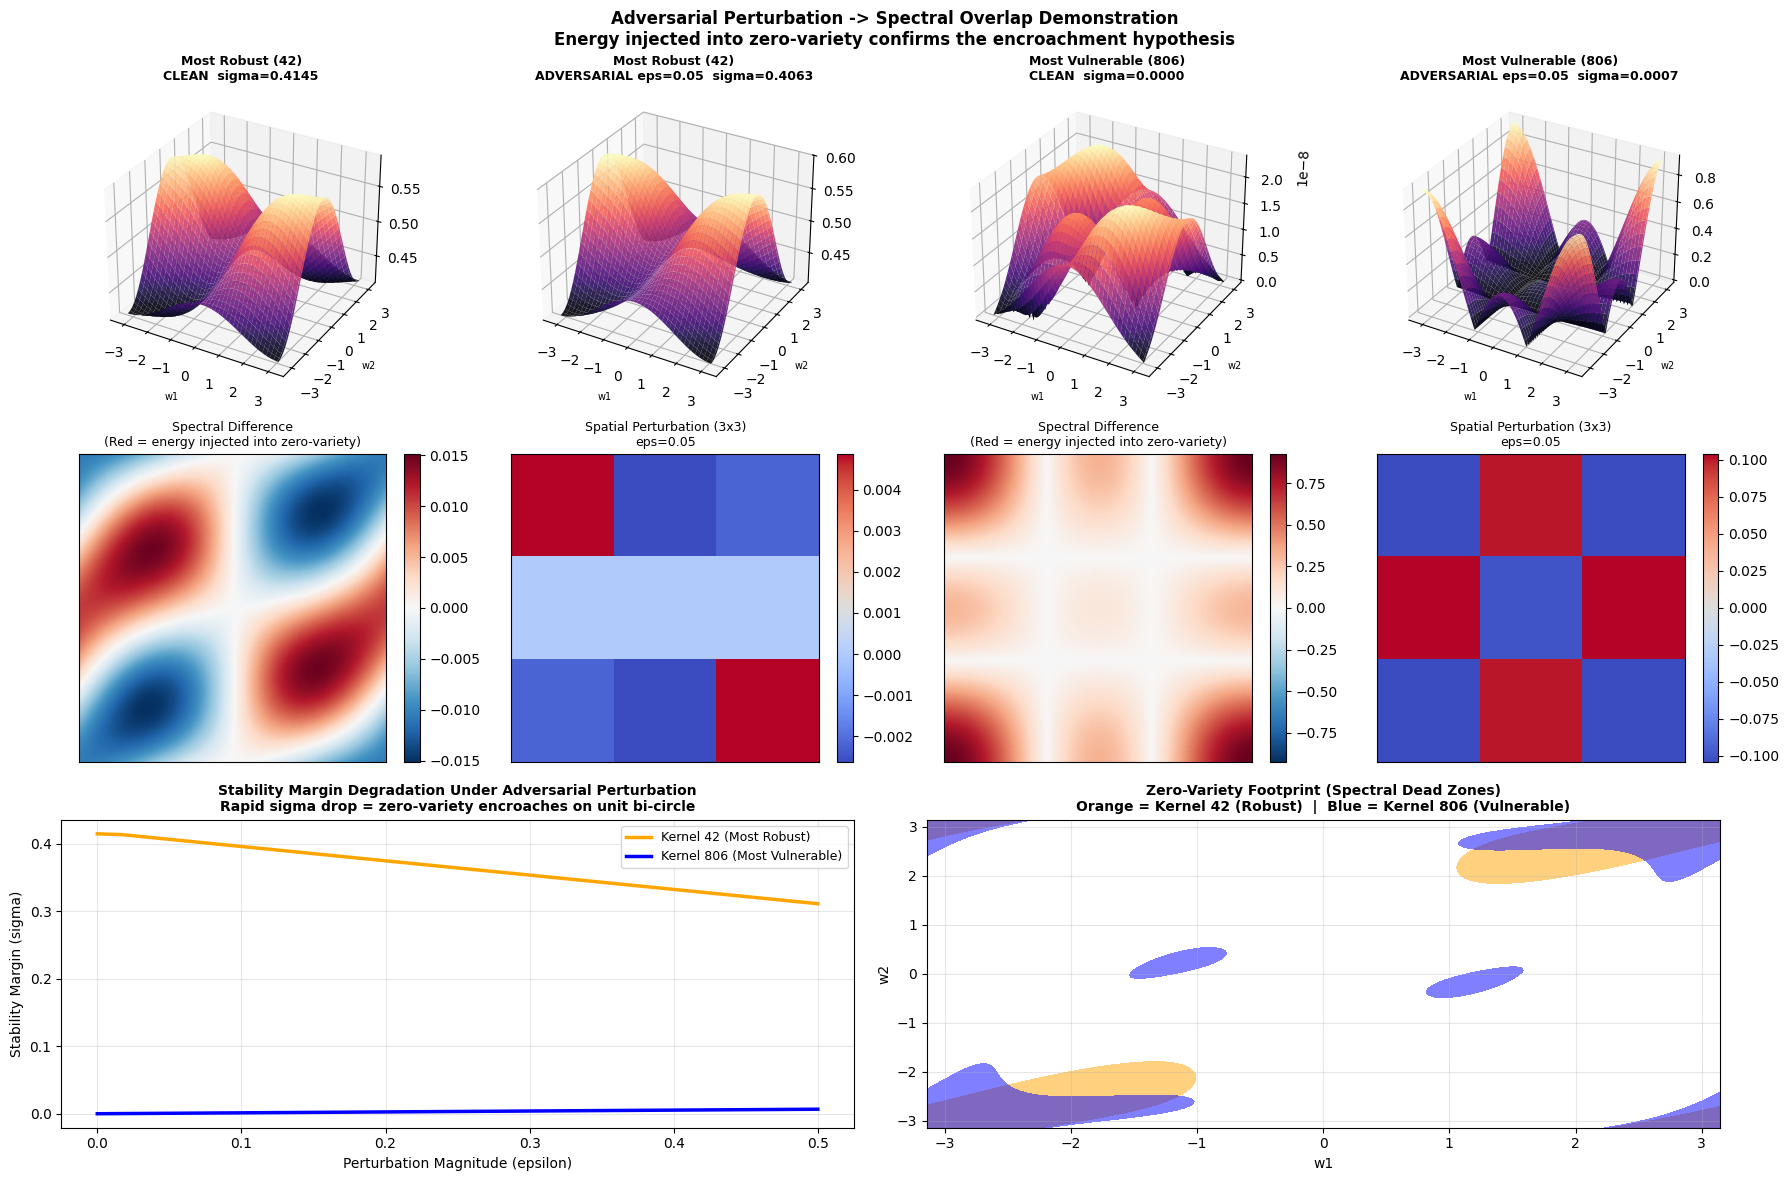

In [136]:
omega = np.linspace(-np.pi, np.pi, GRIDSIZE)
W1, W2 = np.meshgrid(omega, omega)

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Adversarial Perturbation -> Spectral Overlap Demonstration\n" "Energy injected into zero-variety confirms the encroachment hypothesis", fontsize=12, fontweight='bold')
configs = [(IDXROBUST, "Most Robust (42)", 0.05, "orange"), (IDXVULNERABLE, "Most Vulnerable (806)", 0.05, "blue")]

for col, (idx, label, epsilon, color) in enumerate(configs):
    hclean = kernels[idx]
    hperturbed, perturbation = fsgmPerturbation(hclean, epsilon=epsilon)
    magClean = computeMagnitudeResponse(hclean)
    magPerturbed = computeMagnitudeResponse(hperturbed)
    magDiff = magPerturbed - magClean
    sigmac = computeSigma(hclean)
    sigmap = computeSigma(hperturbed)

    ax1 = fig.add_subplot(gs[0, col*2], projection='3d')
    ax1.plot_surface(W1, W2, magClean, cmap='magma', edgecolor='none', alpha = 0.9)
    ax1.set_title(f"{label}\nCLEAN  sigma={sigmac:.4f}", fontsize=9, fontweight='bold')
    ax1.set_xlabel("w1", fontsize=7); ax1.set_ylabel("w2", fontsize=7)

    ax2 = fig.add_subplot(gs[0, col*2 + 1], projection='3d')
    ax2.plot_surface(W1, W2, magPerturbed, cmap='magma', edgecolor='none', alpha=0.9)
    ax2.set_title(f"{label}\nADVERSARIAL eps={epsilon}  sigma={sigmap:.4f}",
                  fontsize=9, fontweight='bold')
    ax2.set_xlabel("w1", fontsize=7); ax2.set_ylabel("w2", fontsize=7)


    ax3 = fig.add_subplot(gs[1, col*2])
    vmax = np.max(np.abs(magDiff))
    im = ax3.imshow(magDiff, cmap='RdBu_r', norm=Normalize(vmin=-vmax, vmax=vmax))
    ax3.set_title("Spectral Difference\n(Red = energy injected into zero-variety)", fontsize=9)
    plt.colorbar(im, ax=ax3, fraction=0.046)
    ax3.set_xticks([]); ax3.set_yticks([])


    ax4 = fig.add_subplot(gs[1, col*2 + 1])
    im2 = ax4.imshow(perturbation, cmap='coolwarm')
    ax4.set_title(f"Spatial Perturbation (3x3)\neps={epsilon}", fontsize=9)
    plt.colorbar(im2, ax=ax4, fraction=0.046)
    ax4.set_xticks([]); ax4.set_yticks([])

ax5 = fig.add_subplot(gs[2, :2])
epsFine = np.linspace(0, 0.5, 30)
for idx, label, color in [(IDXROBUST,     f"Kernel {IDXROBUST} (Most Robust)",      "orange"),
                           (IDXVULNERABLE, f"Kernel {IDXVULNERABLE} (Most Vulnerable)", "blue")]:
    hClean = kernels[idx]
    sigsEps = [computeSigma(fsgmPerturbation(hClean, epsilon)[0]) for epsilon in epsFine]
    ax5.plot(epsFine, sigsEps, color=color, linewidth=2.5, label=label)
ax5.set_title("Stability Margin Degradation Under Adversarial Perturbation\n"
              "Rapid sigma drop = zero-variety encroaches on unit bi-circle",
              fontsize=10, fontweight='bold')
ax5.set_xlabel("Perturbation Magnitude (epsilon)", fontsize=10)
ax5.set_ylabel("Stability Margin (sigma)", fontsize=10)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[2, 2:])
magRob = computeMagnitudeResponse(kernels[IDXROBUST])
magVul = computeMagnitudeResponse(kernels[IDXVULNERABLE])
threshRob = np.percentile(magRob, 10)
threshVul = np.percentile(magVul, 10)
ax6.contourf(W1, W2, magRob, levels=[0, threshRob], colors=['orange'], alpha=0.5)
ax6.contourf(W1, W2, magVul, levels=[0, threshVul], colors=['blue'],   alpha=0.5)
ax6.set_title("Zero-Variety Footprint (Spectral Dead Zones)\n"
              "Orange = Kernel 42 (Robust)  |  Blue = Kernel 806 (Vulnerable)",
              fontsize=10, fontweight='bold')
ax6.set_xlabel("w1", fontsize=10); ax6.set_ylabel("w2", fontsize=10)
ax6.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig("AdversarialSpectralOverlap.png", dpi=150, bbox_inches='tight')
plt.show()

